# 🛢️ Oil Region Profitability Analysis 🗼

**Objective:** Develop a machine learning model to identify the most profitable region for opening 200 new oil wells based on predicted oil reserves and risk analysis.

The project aims to:
- Predict the reserve volume of new oil wells.
- Select the top-performing wells from each region.
- Estimate potential profits under a fixed development budget.
- Evaluate financial risk using bootstrapping simulations.
- Choose the region with the highest expected profit and acceptable risk level.

**Project Tasks:**
1. Train a Linear Regression model to predict oil reserve volumes for new wells.
2. Select the 200 wells with the highest predicted reserves from 500 sampled locations.
3. Calculate expected profits considering.
4. Perform risk assessment using bootstrapping.
5. Identify the region with the highest average profit and a risk of loss below 2.5%.

**Problem Type:**
- Linear Regression
- Confidence Interval
- Bootstrapping

**Evaluation Metrics:**
- RMSE (Root Mean Squared Error)
- Total Profit
- Average Profit
- Risk of Loss

## 1. Data Loading and Preparation 📥

### 1.1 Load and Inspect Data 📥🔎

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

In [2]:
#Load dataset into a DataFrame
geodata0 = pd.read_csv('C:/Users/Acer/Downloads/geo_data_0.csv')
geodata1 = pd.read_csv('C:/Users/Acer/Downloads/geo_data_1.csv')
geodata2 = pd.read_csv('C:/Users/Acer/Downloads/geo_data_2.csv') 

In [3]:
#Inspect Data
geodata0.info()
print()
geodata1.info()
print()
geodata2.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  str    
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), str(1)
memory usage: 3.8 MB

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  str    
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), str(1)
memory usage: 3.8 MB

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   ---------

***No missing values were detected in any of the datasets.***

In [4]:
print(geodata0.sample(3))
print()
print(geodata1.sample(3))
print()
print(geodata2.sample(3))

          id        f0        f1        f2    product
49537  SzrV9  1.798457  0.040663  0.743193  33.350532
58801  ZgxiL  0.415944  0.967496  0.576165  41.459972
48167  wIpoM -0.789363  0.584851 -0.782420   9.748438

          id         f0        f1        f2     product
17782  IwLIx  15.988317 -0.021559  5.000382  134.766305
89566  kiow1   3.244225 -3.599459  2.000673   53.906522
44335  YAZfZ  -0.158999 -2.462474  2.000453   53.906522

          id        f0        f1        f2     product
72362  O8rND  1.927478  0.327175 -0.883096   45.388925
73113  obtYw -0.352403  1.974865  3.272225  100.690994
47741  T7L8I  0.103793  1.251171  0.769325   86.376537


In [5]:
#Inspect Basic Correlation
geodata0[['f0', 'f1', 'f2', 'product']].corr()

,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000


**Key Correlations**
1. f0 vs f1 → -0.44 (moderately negative)
A moderate inverse relationship. When f0 increases, f1 tends to decrease.
It is not extremely strong, but it is significant.

2. f2 vs product → 0.48 (moderately positive)
This is the most important relationship in the entire matrix.

***The most important variable is f2. It has the highest correlation with `product` (0.48) and shows weak linear relationships with the other features.***

### 1.2 Data Preprocessing 📋

#### 1.2.1 Check for duplicate values

In [6]:
geodata0.duplicated().sum()

np.int64(0)

In [7]:
geodata1.duplicated().sum()

np.int64(0)

In [8]:
geodata2.duplicated().sum()

np.int64(0)

***There are no duplicate values.***

In [9]:
#Check for duplicate wells (id column)
geodata0[geodata0['id'].duplicated(keep=False)].sort_values('id')

,id,f0,f1,f2,product
66136,74z30,1.084962,-0.312358,6.990771,127.643327
64022,74z30,0.741456,0.459229,5.153109,140.771492
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
3389,A5aEY,-0.039949,0.156872,0.209861,89.249364
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
42529,AGS9W,1.454747,-0.479651,0.683380,126.370504
931,HZww2,0.755284,0.368511,1.863211,30.681774
7530,HZww2,1.061194,-0.373969,10.430210,158.828695
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675
1949,QcMuo,0.506563,-0.323775,-2.215583,75.496502


In [10]:
geodata1[geodata1['id'].duplicated(keep=False)].sort_values('id')

,id,f0,f1,f2,product
5849,5ltQ6,-3.435401,-12.296043,1.999796,57.085625
84461,5ltQ6,18.213839,2.191999,3.993869,107.813044
1305,LHZR0,11.170835,-1.945066,3.002872,80.859783
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625
2721,bfPNe,-9.494442,-5.463692,4.006042,110.992147
82178,bfPNe,-6.202799,-4.820045,2.995107,84.038886
47591,wt4Uk,-9.091098,-8.109279,-0.002314,3.179103
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305


In [11]:
geodata2[geodata2['id'].duplicated(keep=False)].sort_values('id')

,id,f0,f1,f2,product
45404,KUPhW,0.231846,-1.698941,4.990775,11.716299
55967,KUPhW,1.211150,3.176408,5.543540,132.831802
11449,VF7Jo,2.122656,-0.858275,5.746001,181.716817
49564,VF7Jo,-0.883115,0.560537,0.723601,136.233420
44378,Vcm5J,-1.229484,-2.439204,1.222909,137.968290
95090,Vcm5J,2.587702,1.986875,2.482245,92.327572
28039,xCHr8,1.633027,0.368135,-2.378367,6.120525
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641


***The fact that there are repeating IDs, but with different features, suggests that each row is likely a distinct measurement or estimate of the same well, rather than necessarily a duplication error.***

The `id` column will not be used for model training because it is a unique identifier and does not provide predictive geological information.

#### 1.2.2 Define Features and Target

In [12]:
#Region 0
features0 = geodata0.drop(['id', 'product'], axis=1)
target0 = geodata0['product']

#Region 1
features1 = geodata1.drop(['id', 'product'], axis=1)
target1 = geodata1['product']

#Region 2
features2 = geodata2.drop(['id', 'product'], axis=1)
target2 = geodata2['product']

***Important:***

Feature scaling was not required for this project because Linear Regression is not sensitive to feature magnitudes in the same way as distance-based algorithms.

Additionally, the feature ranges appeared reasonably comparable, and model performance was satisfactory without normalization.

## 2. Model Training 🦾

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def train_and_evaluate_model(features, target):
    #Split data (75:25)
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=12345)

    #Train model
    model = LinearRegression()
    model.fit(features_train, target_train)

    #Predict on validation set
    predictions = model.predict(features_valid)

    #Calculate RMSE
    rmse = mean_squared_error(target_valid, predictions) ** 0.5

    #Average predicted volume (useful for later profit analysis)
    avg_prediction = predictions.mean()

    return predictions, target_valid, rmse, avg_prediction

In [14]:
#Run function for the 3 regions.
preds0, valid0, rmse0, avg0 = train_and_evaluate_model(features0, target0)
preds1, valid1, rmse1, avg1 = train_and_evaluate_model(features1, target1)
preds2, valid2, rmse2, avg2 = train_and_evaluate_model(features2, target2)

In [15]:
#Show Results
print("Region 0")
print("RMSE:", rmse0)
print("Average predicted reserves:", avg0)
print()

print("Region 1")
print("RMSE:", rmse1)
print("Average predicted reserves:", avg1)
print()

print("Region 2")
print("RMSE:", rmse2)
print("Average predicted reserves:", avg2)

Region 0
RMSE: 37.5794217150813
Average predicted reserves: 92.59256778438038

Region 1
RMSE: 0.8930992867756165
Average predicted reserves: 68.72854689544603

Region 2
RMSE: 40.02970873393434
Average predicted reserves: 94.96504596800492


In [16]:
#EXTRA
print(target0.describe())
print(target1.describe())
print(target2.describe())

count    100000.000000
mean         92.500000
std          44.288691
min           0.000000
25%          56.497507
50%          91.849972
75%         128.564089
max         185.364347
Name: product, dtype: float64
count    100000.000000
mean         68.825000
std          45.944423
min           0.000000
25%          26.953261
50%          57.085625
75%         107.813044
max         137.945408
Name: product, dtype: float64
count    100000.000000
mean         95.000000
std          44.749921
min           0.000000
25%          59.450441
50%          94.925613
75%         130.595027
max         190.029838
Name: product, dtype: float64


For Region 0, the RMSE is 37.58, with an estimated average reserve of 92.59 thousand barrels. The well with the highest estimated reserve contains 185.36 thousand barrels.

For Region 1, the RMSE is the lowest at 0.89, indicating highly accurate predictions. However, this region also has the lowest estimated average reserve, at 68.73 thousand barrels. The well with the highest reserve contains 137.95 thousand barrels.

For Region 2, the RMSE is the highest at 40.03, with an estimated average reserve of 94.96 thousand barrels. The well with the largest reserve contains 190.03 thousand barrels.

Overall, while Region 1 provides the most accurate predictions, its estimated reserve volumes are considerably lower than those of Regions 0 and 2, which show higher reserve estimates but also substantially larger prediction errors.

## 3. Preparation for Profit Calculation 📊

**Key Values**

200 wells

Budget = $100M USD

Revenue per unit = $4,500 USD
Product = Thousands of barrels

In [17]:
#Store constants
budget = 100_000_000      #100 million dollars
wells = 200               #Number of wells to develop
revenue_per_unit = 4500   #Revenue per thousand barrels

In [18]:
#Minimum reserves required per well to avoid losses
break_even_volume = budget / wells / revenue_per_unit

print("Break-even volume per well:", break_even_volume)

Break-even volume per well: 111.11111111111111


***This means that each well needs to produce at least 111.1 thousand barrels to recover the investment.***

In [19]:
#Compare with average reserves
print("Break-even volume:", break_even_volume)
print()

print("Region 0 average reserves:", avg0)
print("Region 1 average reserves:", avg1)
print("Region 2 average reserves:", avg2)

Break-even volume: 111.11111111111111

Region 0 average reserves: 92.59256778438038
Region 1 average reserves: 68.72854689544603
Region 2 average reserves: 94.96504596800492


No single region reaches the minimum required average volume.

Developing all wells indiscriminately would likely not be profitable.

Region 1 stands out for its extremely low RMSE, indicating highly accurate predictions, although its average reserves are significantly lower than the other regions.

***How to prepare the step for calculating profit.***

The average predicted reserves in all three regions are below the threshold (111.11), which suggests that developing wells without selection would likely lead to losses.

However, the company’s strategy is to select only the top-performing wells based on predicted reserves. Therefore, the next stage will focus on identifying the 200 wells with the highest predicted production and calculating the expected profit using their actual reserve values.

Additionally, the prediction accuracy of each model will play an important role in the reliability of the profit estimates, especially considering that Region 1 showed significantly lower RMSE than the other regions.

## 4. Calculation of the Profit from a Set of selected Oil Wells and Modeling of Predictions 📈💰

***Tasks:***

- Take predictions and actual values
- Select the 200 wells with the highest predictions
- Obtain the actual reserves for those wells
- Calculate revenue
- Subtract investment

In [20]:
#Create Profit Function
def calculate_profit(predictions, target, count):
    #Convert to Series and reset indexes
    predictions = pd.Series(predictions).reset_index(drop=True)
    target = target.reset_index(drop=True)

    #Select top wells with highest predictions
    top_wells = predictions.sort_values(ascending=False).head(count)

    #Get actual reserves for selected wells
    selected_reserves = target[top_wells.index]

    #Calculate total reserves
    total_reserves = selected_reserves.sum()

    #Calculate revenue
    revenue = total_reserves * revenue_per_unit

    #Calculate profit
    profit = revenue - budget

    return profit, total_reserves

In [21]:
#Run Profit Function for the 3 regions
profit0, reserves0 = calculate_profit(preds0, valid0, 200)
profit1, reserves1 = calculate_profit(preds1, valid1, 200)
profit2, reserves2 = calculate_profit(preds2, valid2, 200)

print("Region 0")
print("Total reserves:", reserves0)
print("Profit:", profit0)
print()

print("Region 1")
print("Total reserves:", reserves1)
print("Profit:", profit1)
print()

print("Region 2")
print("Total reserves:", reserves2)
print("Profit:", profit2)

Region 0
Total reserves: 29601.83565142189
Profit: 33208260.43139851

Region 1
Total reserves: 27589.081548181137
Profit: 24150866.966815114

Region 2
Total reserves: 28245.22214133296
Profit: 27103499.635998324


Although Region 1 achieved the lowest RMSE, indicating highly reliable predictions, Region 0 generated the highest estimated profit after selecting the top 200 wells.

This suggests that higher average reserves in Region 0 compensated for its larger prediction error.

At this stage, Region 0 appears to be the most profitable candidate for development. However, a final decision should also consider financial risk and uncertainty through bootstrapping analysis.

## 5. Calculation of Risks and Profits for Each Region (Bootstrapping) 🛡️💰💸

In [22]:
#Create Bootstrap function
def bootstrap_profit(target, predictions):
    predictions = pd.Series(predictions).reset_index(drop=True)
    target = pd.Series(target).reset_index(drop=True)

    state = np.random.RandomState(12345)

    profits = []

    for i in range(1000):
        target_subsample = target.sample(n=500, replace=True, random_state=state)

        predictions_subsample = predictions.iloc[target_subsample.index]

        profit, _ = calculate_profit(predictions_subsample, target_subsample, 200)

        profits.append(profit)

    profits = pd.Series(profits)

    mean_profit = profits.mean()

    lower = profits.quantile(0.025)
    upper = profits.quantile(0.975)

    risk = (profits < 0).mean() * 100

    return profits, mean_profit, lower, upper, risk

In [23]:
#Run Bootstrap Function for the 3 Regions
profits0, mean0, low0, up0, risk0 = bootstrap_profit(valid0, preds0)
profits1, mean1, low1, up1, risk1 = bootstrap_profit(valid1, preds1)
profits2, mean2, low2, up2, risk2 = bootstrap_profit(valid2, preds2)

In [24]:
#Show Results
print("Region 0")
print(profits0.head())
print()

print("Region 1")
print(profits1.head())
print()

print("Region 2")
print(profits2.head())

Region 0
0    6.054641e+06
1    5.363934e+06
2    2.937858e+06
3    1.789934e+06
4    2.719929e+06
dtype: float64

Region 1
0    2.280162e+06
1    3.343157e+06
2    2.537047e+06
3    6.139661e+06
4    3.571430e+06
dtype: float64

Region 2
0   -7.189923e+05
1    6.459964e+06
2    6.261756e+06
3    4.123517e+06
4   -5.596049e+05
dtype: float64


<Axes: >

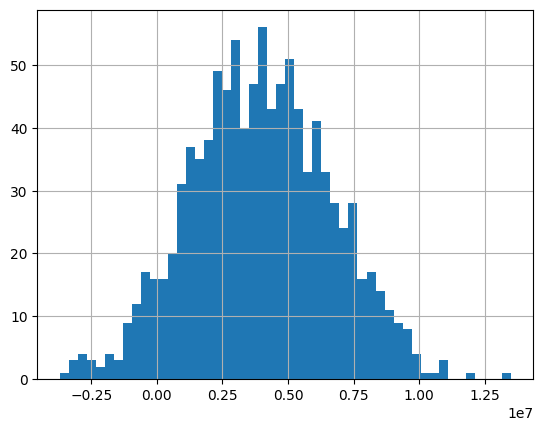

In [25]:
#Show Distribution (Histogram)
profits0.hist(bins=50)

<Axes: >

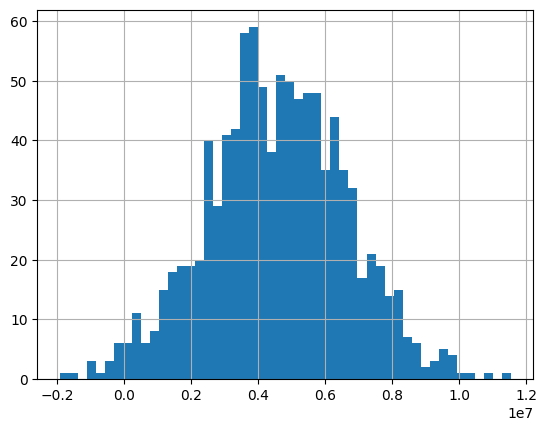

In [26]:
profits1.hist(bins=50)

<Axes: >

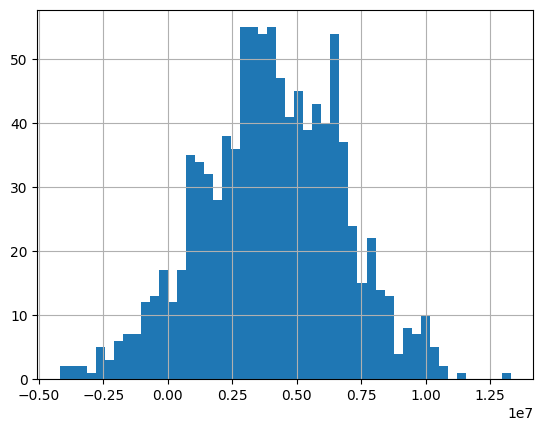

In [27]:
profits2.hist(bins=50)

Bootstrapping with 1000 samples was applied to estimate the distribution of profits for each region.

For every iteration:

* 500 wells were sampled with replacement.
* The top 200 wells were selected based on predicted reserves.
* Profit was calculated using the actual reserves of the selected wells.

This simulation approach allows estimating not only expected profit, but also the uncertainty and financial risk associated with each region.

## Summary Table 📌

In [28]:
#Save results in a DataFrame (Summary Table)
bootstrap_results = pd.DataFrame({
    'Region': ['0', '1', '2'],
    'Average Profit': [mean0, mean1, mean2],
    '95% CI Lower': [low0, low1, low2],
    '95% CI Upper': [up0, up1, up2],
    'Risk of Loss (%)': [risk0, risk1, risk2]})

In [29]:
#Convert to Millions
money_columns = ['Average Profit', '95% CI Lower', '95% CI Upper']

bootstrap_results[money_columns] = (bootstrap_results[money_columns] / 1_000_000)

#Rename Columns
bootstrap_results.rename(columns={
    'Average Profit': 'Average Profit (Million USD)',
    '95% CI Lower': '95% CI Lower (Million USD)',
    '95% CI Upper': '95% CI Upper (Million USD)'
}, inplace=True)

In [30]:
print(bootstrap_results)

  Region  Average Profit (Million USD)  95% CI Lower (Million USD)  \
0      0                      3.961650                   -1.112155   
1      1                      4.560451                    0.338205   
2      2                      4.044039                   -1.633504   

   95% CI Upper (Million USD)  Risk of Loss (%)  
0                    9.097669               6.9  
1                    8.522895               1.5  
2                    9.503596               7.6  


The bootstrapping analysis provided estimates of the average profit, confidence intervals, and probability of financial loss for each region.

The risk of loss was calculated as the percentage of bootstrap samples with negative profit values.

Regions with a risk higher than 2.5% do not satisfy the requirements and should not be considered for development.

## Final Conclusion 🏁

Although Region 0 showed the highest estimated profit during the initial profit calculation, the bootstrapping analysis revealed a higher probability of financial loss.

**Region 1** demonstrated the lowest risk of loss while maintaining stable and positive average profits. Additionally, its prediction model achieved the lowest RMSE, indicating highly reliable reserve estimates.

Since one requirement was to select a region with a loss risk below 2.5%, **Region 1 is the only candidate for oil well development.** The confidence interval for Region 1 remained mostly positive, reinforcing the stability and reliability of its projected profits compared to the other regions.